# Single Type Experiment

In [1]:
import warnings;
warnings.filterwarnings('ignore');

from time import sleep
from tqdm.auto import tqdm

import sys
import importlib
import numpy as np
import nbformat
import pandas as pd
import scipy.optimize as optimization
import matplotlib.pyplot as plt
import seaborn as sns

### Confidence Radius

In [2]:
cthresh = 1
cup = 1
clow = 1
Linf = 1/3

### Offline Optimal Solution

In [3]:
def offline_opt(budget, size, mean, lower_thresh):
    return [budget / np.sum(size) for i in range(len(size))]

### Threshold Based Algorithms

In [4]:
def fixed_threshold(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    rem = len(size)
    size_future = size[0] + np.sum(mean[1:])

    
    for i in range(len(allocation)):
        allocation[i] = min(budget_remaining / size[i], thresh_lower)
        budget_remaining -= allocation[i] * size[i]
        
    return allocation

In [5]:
def hope_guardrail_13(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
    
    Linf = 1/3
    
    rem = len(size)
    
    thresh_upper = thresh_lower + (cthresh / (rem**Linf))
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem))
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [6]:
def hope_guardrail_12(budget, size, mean, thresh_lower):
    allocation = np.zeros(len(size))
    budget_remaining = budget
    
     
    rem = len(size)    
    Linf = 1/2
    
    
    thresh_upper = thresh_lower + (cthresh / (rem**Linf))
    
    
    for i in range(len(allocation)):
    
        rem = len(allocation) - i
        conf_bnd = np.sqrt(np.mean(mean)*(rem))
        
        
        if budget_remaining / size[i] < thresh_lower:
            # print(str(i) + ' giving rest of budget!')
            allocation[i] = budget_remaining / size[i]
        
        
        
        elif budget_remaining >= thresh_lower * (np.sum(mean[i+1:]) + clow*conf_bnd) + size[i] * thresh_upper:
            allocation[i] = thresh_upper

        else:
            allocation[i] = thresh_lower

            
        budget_remaining -= allocation[i] * size[i]

        
    if np.round(budget_remaining, 3) < 0:
        print(budget_remaining)
        print('Error: Negative Budget')
                
        
    return allocation



In [7]:
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D


def radar_factory(num_vars, frame='circle'):
    """Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle' | 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):

        name = 'radar'

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.concatenate((x, [x[0]]))
                y = np.concatenate((y, [y[0]]))
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

        def draw(self, renderer):
            """ Draw. If frame is polygon, make gridlines polygon-shaped """
            if frame == 'polygon':
                gridlines = self.yaxis.get_gridlines()
                for gl in gridlines:
                    gl.get_path()._interpolation_steps = num_vars
            super().draw(renderer)


        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)


                return {'polar': spine}
            else:
                raise ValueError("unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta



In [8]:
def normalize(df):
    result = df.copy()
    for feature_name in df.columns:
        max_value = df[feature_name].max()
        min_value = df[feature_name].min()
        result[feature_name] = (df[feature_name] - min_value) / (max_value - min_value)
                
    return result

### Group by Group Difference

In [29]:
fair_data = []
data = []

n = 6
num_iterations = 100

algo_list = [fixed_threshold, hope_guardrail_12, hope_guardrail_13]

mean_size = np.asarray([26.72, 34.55, 12.09, 12.35, 2.96, 11.31])
expected_size = np.zeros(n) + mean_size

for i in tqdm(range(num_iterations)):
    
    expected_size = np.zeros(n) + mean_size
    budget = n
    size = 1 + np.random.poisson(size=n, lam=mean_size - 1)
    
    size_future = size[0] + np.sum(expected_size[1:])
    rem = n - 1

    lower_thresh = (budget / size_future)*(1 - (np.sqrt(cthresh*rem*np.log(rem)) / size_future) - (cthresh*np.log(rem) / size_future))

    
    opt = offline_opt(budget, size, expected_size, lower_thresh)
    for algo in algo_list:
        sol = algo(budget, size, expected_size, lower_thresh)
        
        
        
        
        for j in range(n):
            data.append({'Location':j, 'Algorithm':algo.__name__, 'Value': opt[j] - sol[j]})
            
        fair_data.append({'Iteration':i, 
                        'Algorithm':algo.__name__, 
                        'Waste':(budget - np.sum(sol)) / n, 
                        'True Envy':np.max(sol) - np.min(sol), 
                        'Envy': np.max(np.abs(sol-opt)), 
                        'Proportional':budget / np.sum(size) - np.min(sol),
                         'Nash Social Welfare': np.log(np.prod(np.power(np.asarray(sol), np.asarray(size))))})
            
    for i in range(n):
        data.append({'Location': i, 'Algorithm':'Zero', 'Value': 0})

  0%|          | 0/100 [00:00<?, ?it/s]

### Printing Fairness Metrics

In [37]:
fair_df = pd.DataFrame.from_records(fair_data)
fair_df = fair_df.assign(Algorithm = lambda df: df.Algorithm.replace({'fixed_threshold': 'Fixed Threshold', 'hope_guardrail_13': 'Guarded Hope $L_T = T^{-1/3}$', 'hope_guardrail_12': 'Guarded Hope $L_T = T^{-1/2}$'}))



fair_df = fair_df.groupby(['Algorithm']).mean()
print(fair_df.drop(['Iteration'], axis=1))

                                  Waste  True Envy      Envy  Proportional  \
Algorithm                                                                    
Fixed Threshold                0.943907   0.003762  0.007570       0.00757   
Guarded Hope $L_T = T^{-1/2}$  0.941866   0.016009  0.019070       0.00757   
Guarded Hope $L_T = T^{-1/3}$  0.942990   0.009265  0.012867       0.00757   

                               Nash Social Welfare  
Algorithm                                           
Fixed Threshold                               -inf  
Guarded Hope $L_T = T^{-1/2}$                 -inf  
Guarded Hope $L_T = T^{-1/3}$                 -inf  


In [38]:
fair_df = normalize(fair_df).drop(['Iteration'], axis=1)
print(fair_df)

                                  Waste  True Envy      Envy  Proportional  \
Algorithm                                                                    
Fixed Threshold                1.000000   0.000000  0.000000           NaN   
Guarded Hope $L_T = T^{-1/2}$  0.000000   1.000000  1.000000           NaN   
Guarded Hope $L_T = T^{-1/3}$  0.550665   0.449335  0.460613           NaN   

                               Nash Social Welfare  
Algorithm                                           
Fixed Threshold                                NaN  
Guarded Hope $L_T = T^{-1/2}$                  NaN  
Guarded Hope $L_T = T^{-1/3}$                  NaN  


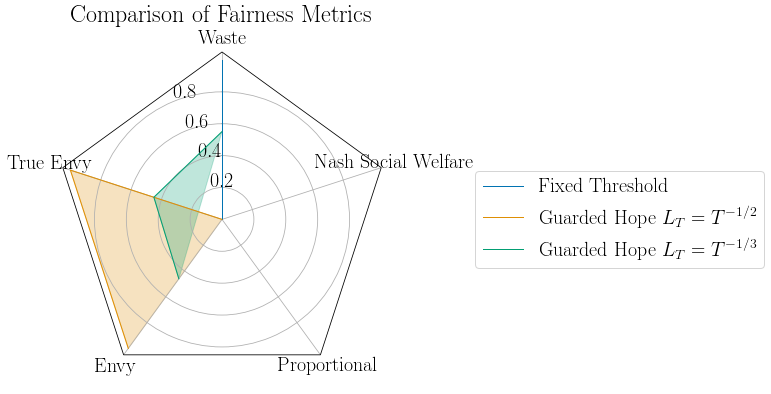

In [41]:
# number of variable



plt.style.use('PaperDoubleFig.mplstyle.txt')


from math import pi


plt.rc('text', usetex=True)




N = len(list(fair_df))
theta = radar_factory(N, frame='polygon')

spoke_labels = list(fair_df)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection='radar'))
fig.subplots_adjust(top=0.85, bottom=0.05)

ax.set_rgrids([0.2, 0.4, 0.6, 0.8])
ax.set_title('Comparison of Fairness Metrics',  position=(0.5, 1.1), ha='center')

index = 0
for algo in algo_list:
    values = fair_df.iloc[index, :].to_numpy()
    ax.plot(theta, values, linewidth=1, linestyle='solid', label=fair_df.index[index], color = sns.color_palette('colorblind', len(algo_list))[index])
    ax.fill(theta, values, color = sns.color_palette('colorblind', len(algo_list))[index],  alpha=0.25)
    index += 1
ax.set_varlabels(spoke_labels)

plt.legend(loc='right', bbox_to_anchor=(2.15, .5))

plt.show()
# plt.savefig('radar.pdf')



